# 🔍 Exploração do HealDB via Jupyter

Este notebook tem como objetivo explorar o conteúdo do banco HealDB, com base nos:

- Medicamentos 
- Princípios ativos
- Associação medicamento-doença
- Interações Medicamentosas
- Interações Medicamento X Alimento


Cada seção contém perguntas exploratórias com visualizações e análises. A conexão é feita via SQLAlchemy.
Inicialmente é feita a leitura de todas as tabelas envolvidas na exploração dos dados.

In [3]:
# Importação das bibliotecas necessárias
import sys, time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap


In [4]:
## Conexão com o HealDB via SQLAlchemy
sys.path.append("C:\\project\\healdb")
from db_utils import open_connection_alchemy, close_connection_alchemy

engine = open_connection_alchemy()

In [5]:
## Leitura da tabela de Medicamentos
sql_command = '''
SELECT 
    m.id_medication, 
    m.nr_register, 
    m.nm_medication, 
    r.ds_regulatory_category,
    m.dt_expiration, 
    t.ds_therapeutic_class, 
    m.id_company, 
    c.nr_cnpj_company, 
    c.nm_company,
    m.fl_status, 
    m.ds_active_ingredients
FROM hd_medication m
JOIN hd_medication_drug_leaflet l ON l.id_medication = m.id_medication
JOIN hd_regulatory_category r ON m.id_regulatory_category = r.id_regulatory_category
JOIN hd_therapeutic_class t ON m.id_therapeutic_class = t.id_therapeutic_class
JOIN hd_company c ON m.id_company = c.id_company
'''
df_med = pd.read_sql(sql_command, con=engine)
df_med.head()

,id_medication,nr_register,nm_medication,ds_regulatory_category,dt_expiration,ds_therapeutic_class,id_company,nr_cnpj_company,nm_company,fl_status,ds_active_ingredients
0,103,183260400,ADACEL,BIOLÓGICO,2028-03-01,VACINAS,513,10588595001092,SANOFI MEDLEY FARMACÊUTICA LTDA.,VÁLIDO,AGLUTINÓGENOS FIMBRIAIS DE BORDETELLA PERTUSSI...
1,109,106390269,ADCETRIS,BIOLÓGICO,2029-09-01,ANTINEOPLASICO,562,60397775000174,TAKEDA PHARMA LTDA.,VÁLIDO,BRENTUXIMABE VEDOTINA
2,126,106390288,ADVATE,BIOLÓGICO,2029-07-01,OUTROS PRODUTOS QUE ATUAM NO SANGUE E HEMATOPO...,562,60397775000174,TAKEDA PHARMA LTDA.,VÁLIDO,ALFAOCTOCOGUE
3,128,106390297,ADYNOVATE,BIOLÓGICO,2030-01-01,OUTROS PRODUTOS QUE ATUAM NO SANGUE E HEMATOPO...,562,60397775000174,TAKEDA PHARMA LTDA.,VÁLIDO,ALFARURIOCTOCOGUE PEGOL
4,139,133480002,AFREZZA,BIOLÓGICO,2029-06-01,ANTIDIABETICOS,573,04752991000110,BIOMM SA,VÁLIDO,INSULINA HUMANA


In [6]:
## Leitura da tabela de Medicamentos e Doenças
sql_command = '''
select d.id_med_disease, d.id_medication, m.nm_medication, c1.nm_company, d.cd_icd_full,
       g.ds_group, c.cd_cat, c.ds_cat, s.cd_subcat, s.ds_subcat, c.ds_cat_eng, 
       s.ds_subcat_eng, d.vl_score, d.vl_entity_score, d.fl_low_confidence, 
       d.nm_trait_main, d.vl_trait_main_score, m.ds_active_ingredients, concat (c.cd_cat, '-', s.cd_subcat) cid_10
from hd_medication_disease d
JOIN hd_medication m ON m.id_medication = d.id_medication
JOIN hd_company c1 ON c1.id_company = m.id_company
LEFT JOIN hd_icd_group g ON g.id_group = d.id_icd_group
LEFT JOIN hd_icd_category c ON c.id_cat = d.id_icd_cat and c.id_group = d.id_icd_group
LEFT JOIN hd_icd_subcategory s ON s.id_subcat = d.id_icd_subcat
'''
df_med_disease = pd.read_sql(sql_command, con=engine)
df_med_disease.head()

,id_med_disease,id_medication,nm_medication,nm_company,cd_icd_full,ds_group,cd_cat,ds_cat,cd_subcat,ds_subcat,ds_cat_eng,ds_subcat_eng,vl_score,vl_entity_score,fl_low_confidence,nm_trait_main,vl_trait_main_score,ds_active_ingredients,cid_10
0,1,4,ABBA,SUN FARMACÊUTICA DO BRASIL LTDA,C61,Neoplasias malignas dos órgãos genitais mascul...,C61,Neoplasia maligna da próstata,C61,Neoplasia maligna da próstata,Malignant neoplasm of prostate,Malignant neoplasm of prostate,0.666887,0.920151,1,DIAGNOSIS,0.878773,ACETATO DE ABIRATERONA,C61-C61
1,2,4,ABBA,SUN FARMACÊUTICA DO BRASIL LTDA,C79.82,Neoplasias malignas de localizações mal defini...,C79,Neoplasia maligna secundária de outras localiz...,None,None,Secondary malignant neoplasm of other sites,None,0.609814,0.920151,1,DIAGNOSIS,0.878773,ACETATO DE ABIRATERONA,None
2,3,5,ABC,KLEY HERTZ FARMACEUTICA S.A,L21,Dermatite e eczema,L21,Dermatite seborréica,None,None,Seborrhoeic dermatitis,None,0.818795,0.892153,0,DIAGNOSIS,0.779019,CLOTRIMAZOL,None
3,4,5,ABC,KLEY HERTZ FARMACEUTICA S.A,L21.0,Dermatite e eczema,L21,Dermatite seborréica,L210,Seborréia do couro cabeludo,Seborrhoeic dermatitis,Seborrhoea capitis,0.717626,0.892153,0,DIAGNOSIS,0.779019,CLOTRIMAZOL,L21-L210
4,5,5,ABC,KLEY HERTZ FARMACEUTICA S.A,L21.1,Dermatite e eczema,L21,Dermatite seborréica,L211,Dermatite seborréica infantil,Seborrhoeic dermatitis,Seborrhoeic infantile dermatitis,0.717696,0.892153,0,DIAGNOSIS,0.779019,CLOTRIMAZOL,L21-L211


In [7]:
## Leitura da tabela de Princípios Ativos
sql_command = '''
SELECT a.id_active_ingredient, a.nm_active_ingredient, t.nm_active_ingredient_eng
FROM hd_active_ingredient a,
     hd_translate_eng_active_ing t
WHERE t.id_active_ingredient = a.id_active_ingredient
'''
df_ai = pd.read_sql(sql_command, con=engine)
df_ai.head()

,id_active_ingredient,nm_active_ingredient,nm_active_ingredient_eng
0,1,EXTRATO FLUIDO DE CASCA DE LARANJA AMARGA,BITTER ORANGE FRUIT
1,2,EXTRATO FLUIDO DE PASSIFLORA ALATA,PASSIFLORA INCARNATA FLOWER EXTRACT
2,3,SALICILATO DE SÓDIO,SODIUM SALICYLATE
3,4,TINTURA AGONIADA PLUMÉRIA,AGONIZED PLUMERIA DYE
4,5,ACIDO ACETILSALICILICO,ACETYLSALICYLIC ACID


In [8]:
## Leitura das tabelas de Medicamentos e Princípios Ativos
sql_command = '''
SELECT m.id_medication, m.nm_medication, c.nm_company, a.id_active_ingredient, 
   a.nm_active_ingredient, t.nm_active_ingredient_eng
FROM hd_medication_active_ingredient ma
JOIN hd_active_ingredient a ON ma.id_active_ingredient = a.id_active_ingredient
JOIN hd_medication m ON ma.id_medication = m.id_medication
JOIN hd_company c ON c.id_company = m.id_company
JOIN hd_translate_eng_active_ing t ON ma.id_active_ingredient = t.id_active_ingredient
'''
df_med_ai = pd.read_sql(sql_command, con=engine)
df_med_ai.head()

,id_medication,nm_medication,nm_company,id_active_ingredient,nm_active_ingredient,nm_active_ingredient_eng
0,1,A SAÚDE DA MULHER,EMS S/A,1,EXTRATO FLUIDO DE CASCA DE LARANJA AMARGA,BITTER ORANGE FRUIT
1,1,A SAÚDE DA MULHER,EMS S/A,2,EXTRATO FLUIDO DE PASSIFLORA ALATA,PASSIFLORA INCARNATA FLOWER EXTRACT
2,1,A SAÚDE DA MULHER,EMS S/A,3,SALICILATO DE SÓDIO,SODIUM SALICYLATE
3,1,A SAÚDE DA MULHER,EMS S/A,4,TINTURA AGONIADA PLUMÉRIA,AGONIZED PLUMERIA DYE
4,2,AAS,SANOFI MEDLEY FARMACÊUTICA LTDA.,5,ACIDO ACETILSALICILICO,ACETYLSALICYLIC ACID


In [9]:
## Leitura da tabela de Interações Medicamentosas
sql_command = '''
SELECT d.id_drug_interaction, a.id_active_ingredient, a.nm_active_ingredient, t.nm_active_ingredient_eng, 
       a2.id_active_ingredient id_active_ingredient2, a2.nm_active_ingredient nm_active_ingredient2,
       t2.nm_active_ingredient_eng nm_active_ingredient2_eng,
       p.ds_drug_interaction ds_drug_interaction_port, db.ds_interaction ds_drug_interaction_eng    
FROM hd_drug_interaction d
JOIN hd_active_ingredient a ON d.id_active_ingredient = a.id_active_ingredient
JOIN hd_active_ingredient a2 ON d.id_active_ingredient_2 = a2.id_active_ingredient
JOIN hd_priv_drug_interaction_desc p ON p.id_drug_interaction = d.id_drug_interaction 
JOIN db_drug_interaction db ON db.id_interaction = d.id_interaction
JOIN hd_translate_eng_active_ing t ON t.id_active_ingredient = a.id_active_ingredient
JOIN hd_translate_eng_active_ing t2 ON t2.id_active_ingredient = a2.id_active_ingredient
'''
df_drug_int = pd.read_sql(sql_command, con=engine)
df_drug_int.head()

,id_drug_interaction,id_active_ingredient,nm_active_ingredient,nm_active_ingredient_eng,id_active_ingredient2,nm_active_ingredient2,nm_active_ingredient2_eng,ds_drug_interaction_port,ds_drug_interaction_eng
0,1,1152,CETUXIMABE,CETUXIMAB,1093,ESTROGÊNIOS CONJUGADOS,CONJUGATED ESTROGENS,Estrogênios conjugados pode aumentar as ativid...,Conjugated estrogens may increase the thrombog...
1,2,1152,CETUXIMABE,CETUXIMAB,1919,ESTROGÊNIOS CONJUGADOS NATURAIS,CONJUGATED ESTROGENS,Estrogênios conjugados pode aumentar as ativid...,Conjugated estrogens may increase the thrombog...
2,3,1152,CETUXIMABE,CETUXIMAB,176,ALFAESTRADIOL,ESTRADIOL,Alfaestradiol pode aumentar as atividades trom...,Estradiol may increase the thrombogenic activi...
3,4,1152,CETUXIMABE,CETUXIMAB,292,ESTRADIOL HEMI-HIDRATADO,ESTRADIOL HEMIHYDRATE,Alfaestradiol pode aumentar as atividades trom...,Estradiol may increase the thrombogenic activi...
4,5,1152,CETUXIMABE,CETUXIMAB,1172,ESTRADIOL,ESTRADIOL,Alfaestradiol pode aumentar as atividades trom...,Estradiol may increase the thrombogenic activi...


In [10]:
## Leitura da tabela de Interações Medicamentosas por RXCUI
sql_command = '''
SELECT distinct rx.cd_ext_id AS rxcui, rx2.cd_ext_id AS rxcui2,
       d.id_interaction, p.ds_drug_interaction ds_drug_interaction_port, db.ds_interaction ds_drug_interaction_eng    
FROM hd_drug_interaction d
JOIN hd_active_ingredient a ON d.id_active_ingredient = a.id_active_ingredient
JOIN hd_active_ingredient a2 ON d.id_active_ingredient_2 = a2.id_active_ingredient
JOIN hd_priv_drug_interaction_desc p ON p.id_drug_interaction = d.id_drug_interaction 
JOIN db_drug_interaction db ON db.id_interaction = d.id_interaction
JOIN hd_translate_eng_active_ing t ON t.id_active_ingredient = a.id_active_ingredient
JOIN hd_translate_eng_active_ing t2 ON t2.id_active_ingredient = a2.id_active_ingredient
LEFT JOIN hd_active_ingredient_ext_id rx ON rx.id_active_ingredient = a.id_active_ingredient AND rx.tp_ext_id = 'RXCUI'
LEFT JOIN hd_active_ingredient_ext_id rx2 ON rx2.id_active_ingredient = a2.id_active_ingredient AND rx2.tp_ext_id = 'RXCUI'
'''
df_drug_rxcui_int = pd.read_sql(sql_command, con=engine)
df_drug_rxcui_int.head()

,rxcui,rxcui2,id_interaction,ds_drug_interaction_port,ds_drug_interaction_eng
0,318341,4099,655,Estrogênios conjugados pode aumentar as ativid...,Conjugated estrogens may increase the thrombog...
1,318341,4083,657,Alfaestradiol pode aumentar as atividades trom...,Estradiol may increase the thrombogenic activi...
2,318341,236859,657,Alfaestradiol pode aumentar as atividades trom...,Estradiol may increase the thrombogenic activi...
3,318341,4124,659,Etinilestradiol pode aumentar as atividades tr...,Ethinylestradiol may increase the thrombogenic...
4,318341,4094,661,Estriol pode aumentar as atividades trombogêni...,Estriol may increase the thrombogenic activiti...


In [11]:
## Leitura da tabela de Interações de Alimentos
sql_command = '''
select f.id_food_interaction, a.id_active_ingredient, a.nm_active_ingredient, f.ds_food_interaction
from hd_priv_food_interaction f
JOIN hd_active_ingredient a ON a.id_active_ingredient = f.id_active_ingredient
'''
df_food_int = pd.read_sql(sql_command, con=engine)
df_food_int.head()

,id_food_interaction,id_active_ingredient,nm_active_ingredient,ds_food_interaction
0,1,1867,ALFAPEGINTERFERONA 2A,Beba bastante líquidos.
1,2,65,ALTEPLASE,Evite ervas e suplementos com atividade antico...
2,3,336,ALFADARBEPOETINA,Administrar suplemento de ferro. Ao iniciar um...
3,4,174,ALFAEPOETINA,Administrar suplemento de ferro. Ao iniciar um...
4,5,175,ERITROPOETINA HUMANA RECOMBINANTE,Administrar suplemento de ferro. Ao iniciar um...


## 1. Medicamentos do HealDB

**Perguntas:**
- Quais são as principais classes terapêuticas dos medicamentos do HealDB?
- Existe predominância de alguma categoria regulatória (ex: Genérico, Similar) entre os medicamentos?
- Quais são os medicamentos mais próximos da expiração?
- Quais as empresas que mais fornecem medicamentos?


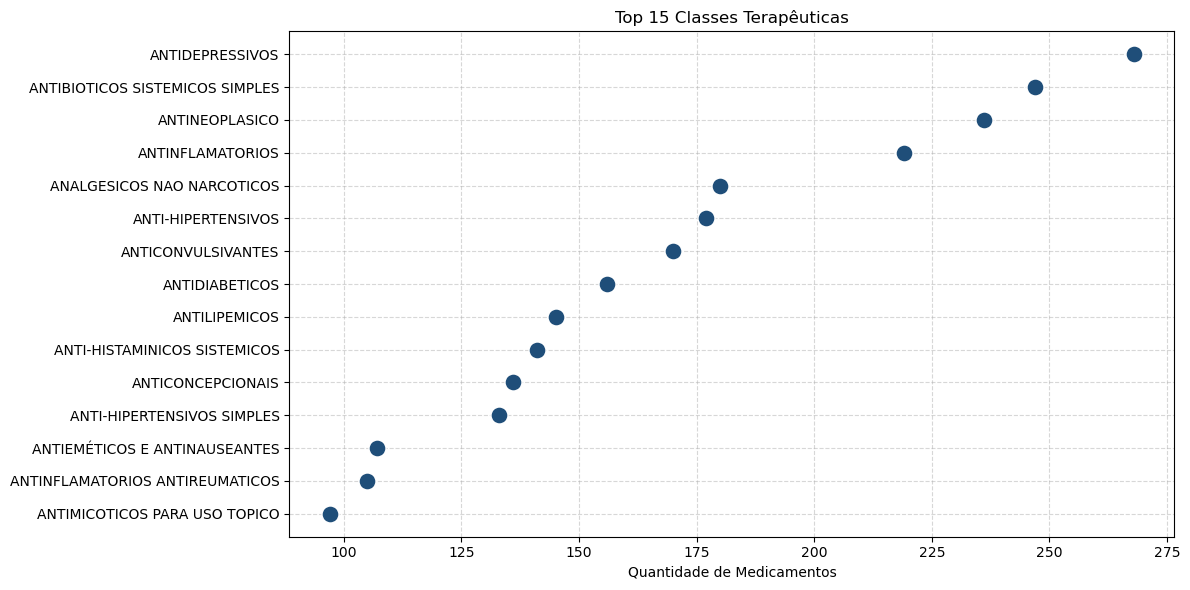

In [12]:
# PERGUNTA: Quais são as principais classes terapêuticas dos medicamentos do HealDB?

# Top 10 classes terapêuticas com mais medicamentos
df_therapeutic = df_med['ds_therapeutic_class'].value_counts().head(15).reset_index()
df_therapeutic.columns = ['Classe Terapêutica', 'Quantidade de Medicamentos']

# Exibe resultado
#print("Top 15 Classes Terapêuticas por quantidade de medicamentos:")
styled_table = df_therapeutic.style.set_table_styles(
    [
        {'selector': 'th', 'props': [('text-align', 'left')]},  
        {'selector': 'td', 'props': [('text-align', 'left')]}   
    ]
).hide(axis="index")  
#display(styled_table)

#plt.figure(figsize=(12, 6))
#sns.barplot(data=df_therapeutic, x='Quantidade de Medicamentos', y='Classe Terapêutica', palette='Oranges_d')
#plt.title('Top 15 Classes Terapêuticas')
#plt.xlabel('Quantidade de Medicamentos')
#plt.ylabel('')
#plt.tight_layout()
#plt.show()

#Cinza elegante: color="#4D4D4D"
#Cinza médio frio: color="#6B7280"
#Grafite suave: color="#374151"
#Azul médio corporativo: color="#1F4E79"

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_therapeutic,
    x='Quantidade de Medicamentos',
    y='Classe Terapêutica',
    s=150,  # tamanho dos pontos
    color='#1F4E79',
    zorder=3  # pontos acima do grid
)

plt.title('Top 15 Classes Terapêuticas')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


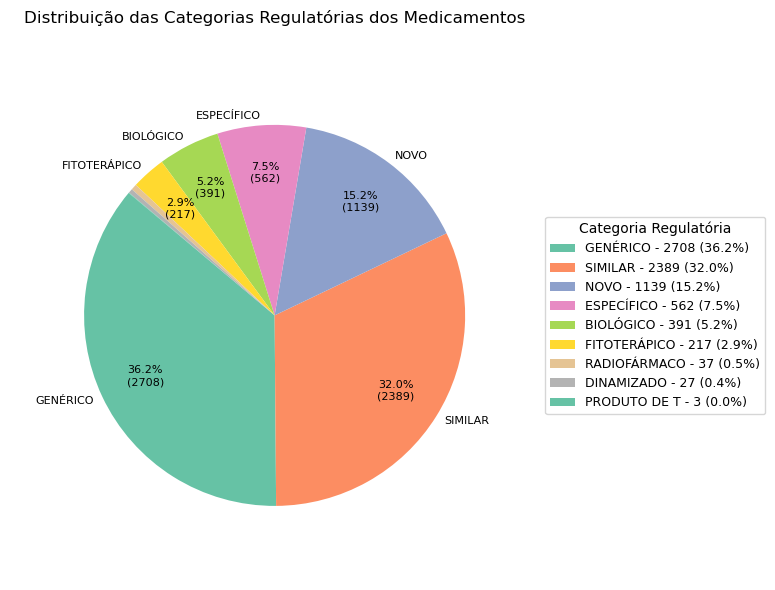

In [13]:
# PERGUNTA: Existe predominância de alguma categoria regulatória (ex: Genérico, Similar) entre os medicamentos?

# Distribuição das categorias regulatórias dos medicamentos
df_reg_cat = df_med['ds_regulatory_category'].value_counts().reset_index()
df_reg_cat.columns = ['Categoria Regulatória', 'Quantidade']

total = df_reg_cat['Quantidade'].sum()
limite_pct_exibir = 2.0  # Exibir rótulo na fatia apenas se pct >= 2%

# Gera os rótulos (apenas se pct >= limite)
labels = []
autopcts = []

for i, row in df_reg_cat.iterrows():
    pct = (row['Quantidade'] / total) * 100
    if pct >= limite_pct_exibir:
        labels.append(row['Categoria Regulatória'])
        autopcts.append(f'{pct:.1f}%\n({row["Quantidade"]})')
    else:
        labels.append('')         
        autopcts.append('')       

colors = plt.cm.Set2.colors

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    df_reg_cat['Quantidade'],
    labels=labels,
    autopct=lambda pct: autopcts.pop(0),
    startangle=140,
    colors=colors,
    radius=0.9,
    labeldistance=1.05,
    pctdistance=0.75,
    textprops={'fontsize': 8}
)

legenda = [
    f"{row['Categoria Regulatória']} - {row['Quantidade']} ({(row['Quantidade']/total):.1%})"
    for _, row in df_reg_cat.iterrows()
]
ax.legend(
    legenda,
    title="Categoria Regulatória",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=9,
    title_fontsize=10
)

plt.title('Distribuição das Categorias Regulatórias dos Medicamentos', pad=20)
plt.tight_layout()
plt.show()


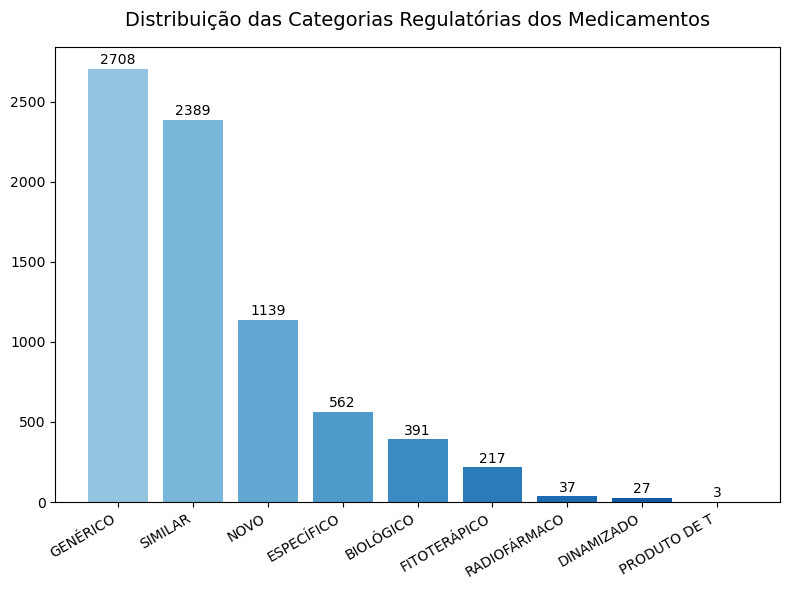

In [14]:
import numpy as np

# Distribuição das categorias regulatórias dos medicamentos
df_reg_cat = df_med['ds_regulatory_category'].value_counts().reset_index()
df_reg_cat.columns = ['Categoria Regulatória', 'Quantidade']

# Ordena por quantidade
df_reg_cat = df_reg_cat.sort_values('Quantidade', ascending=False)

# Cria degradê de azul
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_reg_cat)))

# Gráfico de barras verticais com degradê azul
plt.figure(figsize=(8, 6))
bars = plt.bar(
    df_reg_cat['Categoria Regulatória'],
    df_reg_cat['Quantidade'],
    color=colors
)

# Rótulos com valores acima de cada barra
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        str(int(bar.get_height())),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Distribuição das Categorias Regulatórias dos Medicamentos", fontsize=14, pad=15)
#plt.xlabel("Categoria Regulatória")
#plt.ylabel("Quantidade de Medicamentos")
plt.xticks(rotation=30, ha='right')

# Remove grades
plt.grid(False)

plt.tight_layout()
plt.show()

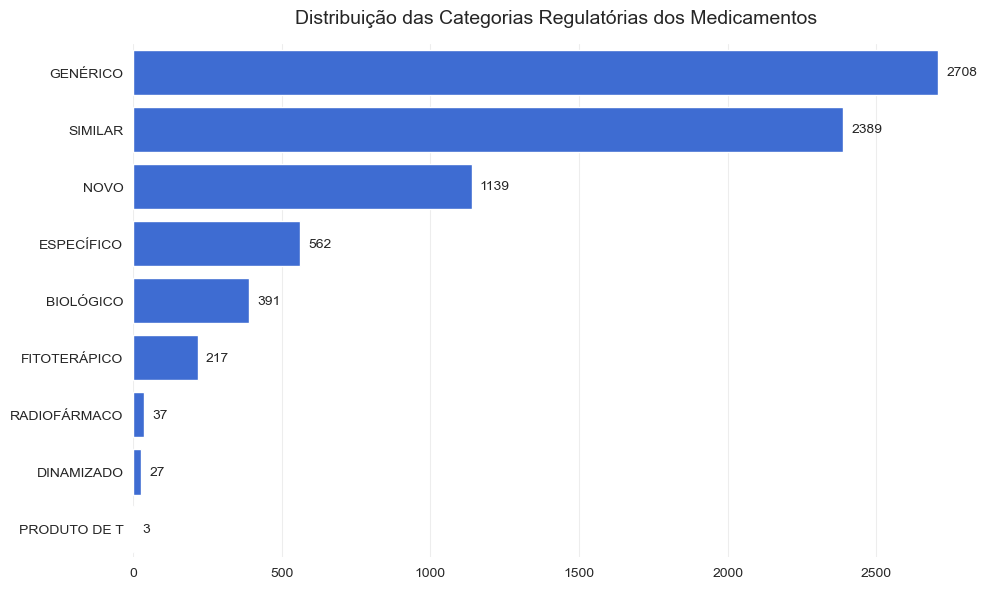

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_reg_cat = (
    df_med['ds_regulatory_category']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'Categoria Regulatória', 'ds_regulatory_category': 'Quantidade'})
    .sort_values('Quantidade', ascending=False)  # maior -> menor
)

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_reg_cat)))

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_reg_cat,
    x='Quantidade',
    y='Categoria Regulatória',
    order=df_reg_cat['Categoria Regulatória'].tolist(),  # garante a ordem
    #palette=colors,
    color='#2563EB',
    zorder=3
)

# Só linhas internas (sem contorno externo)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_axisbelow(True)
ax.xaxis.grid(True, which='major', linestyle='-', linewidth=0.8, alpha=0.35)
ax.yaxis.grid(False)

# Rótulos ao fim das barras
max_q = df_reg_cat['Quantidade'].max()
for p in ax.patches:
    w = p.get_width()
    y = p.get_y() + p.get_height()/2
    ax.text(w + max_q*0.01, y, f'{int(w)}', va='center', ha='left', fontsize=10)

ax.set_title('Distribuição das Categorias Regulatórias dos Medicamentos', fontsize=14, pad=15)
ax.set_ylabel('')
ax.set_xlabel('')

plt.tight_layout()
plt.show()


In [16]:
# PERGUNTA: Quais são os medicamentos mais próximos da expiração?

# Converte dt_expiration para datetime, se necessário
df_med['dt_expiration'] = pd.to_datetime(df_med['dt_expiration'], errors='coerce')

# Filtra medicamentos com data futura e ordenar 
df_expiring = df_med[df_med['dt_expiration'] > pd.Timestamp.today()].sort_values('dt_expiration').head(10)

# Exibe os 10 mais próximos da expiração
print("\n Medicamentos mais próximos da data de expiração:")
df_expiring = df_expiring[['id_medication', 'nm_medication', 'dt_expiration', 'ds_regulatory_category', 'ds_therapeutic_class']]

df_expiring = df_expiring.rename(columns={
    'id_medication': 'Id Medicamento',
    'nm_medication': 'Medicamento',
    'dt_expiration': 'Data Expiração',
    'ds_regulatory_category': 'Categoria Regulatória',
    'ds_therapeutic_class': 'Classe Terapêutica'
})
styled_table = df_expiring.style.set_table_styles(
    [
        {'selector': 'th', 'props': [('text-align', 'left')]},  # Alinha cabeçalhos à esquerda
        {'selector': 'td', 'props': [('text-align', 'left')]}   # Alinha conteúdo à esquerda
    ]
).hide(axis="index") 
display(styled_table)



 Medicamentos mais próximos da data de expiração:


Id Medicamento,Medicamento,Data Expiração,Categoria Regulatória,Classe Terapêutica
625,Aciclovir,2025-10-01 00:00:00,GENÉRICO,ANTIVIROTICOS
9999,BOSULIF,2025-10-01 00:00:00,NOVO,ANTINEOPLASICO
2459,DIPIRONA + CAFEÍNA,2025-10-01 00:00:00,GENÉRICO,ANALGESICOS NAO NARCOTICOS
8529,cloridrato de venlafaxina,2025-10-01 00:00:00,GENÉRICO,ANTIDEPRESSIVOS
631,Adempas®,2025-10-01 00:00:00,NOVO,ANTI-HIPERTENSIVOS
2363,DICLOFENACO POTÁSSICO,2025-10-01 00:00:00,GENÉRICO,ANTINFLAMATORIOS
8544,clotrimazol + acetato de dexametasona,2025-10-01 00:00:00,GENÉRICO,GLICOCORTICOIDES TOPICOS - ASSOCIACAO MEDICAMENTOSA
7286,UNI-CARBAMAZ,2025-10-01 00:00:00,SIMILAR,ANTICONVULSIVANTES
7666,XIGDUO XR,2025-10-01 00:00:00,NOVO,ANTIDIABETICOS
7861,aciclovir,2025-10-01 00:00:00,GENÉRICO,ANTIVIROTICOS


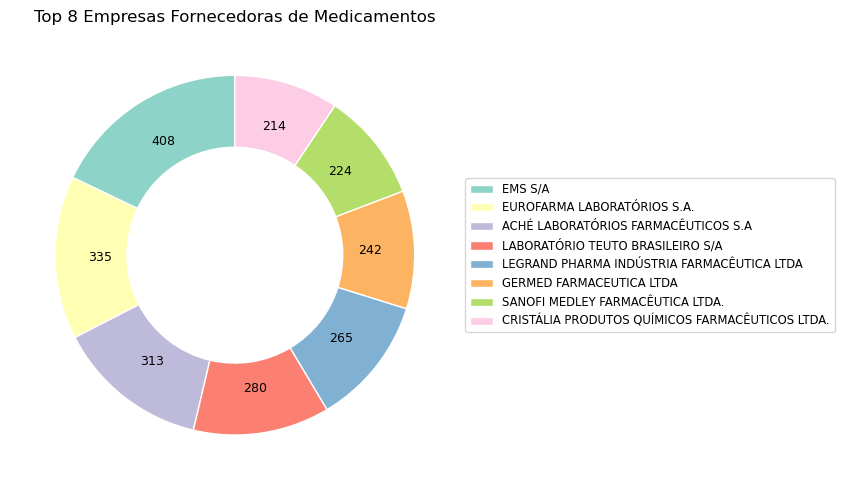

In [17]:
# PERGUNTA: Quais as empresas que mais fornecem medicamentos?

# Agrupa e conta medicamentos por empresa
df_empresas_top8 = (
    df_med['nm_company']
    .value_counts()
    .head(8)
    .reset_index()
    .rename(columns={'index': 'Empresa', 'nm_company': 'Quantidade de Medicamentos'})
)

# Função para mostrar valores absolutos no gráfico
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val}'
    return my_autopct

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('Set3', len(df_empresas_top8))

wedges, texts, autotexts = ax.pie(
    df_empresas_top8['Quantidade de Medicamentos'],
    autopct=make_autopct(df_empresas_top8['Quantidade de Medicamentos']),
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    pctdistance=0.75  # <- controla a posição do número dentro da faixa
)

ax.legend(
    wedges,
    df_empresas_top8['Empresa'],
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize='small'
)

plt.setp(autotexts, size=9)
ax.set_title("Top 8 Empresas Fornecedoras de Medicamentos")
plt.tight_layout()
plt.show()


## 2. Princípios ativos

**Perguntas:**
- Quais são os TOP 10 princípios ativos mais utilizados? 
- Quais são os princípios ativos que estão presentes no maior número de medicamentos, em ordem decrescente de ocorrência?
- Quais medicamentos existentes contêm um determinado princípio ativo?


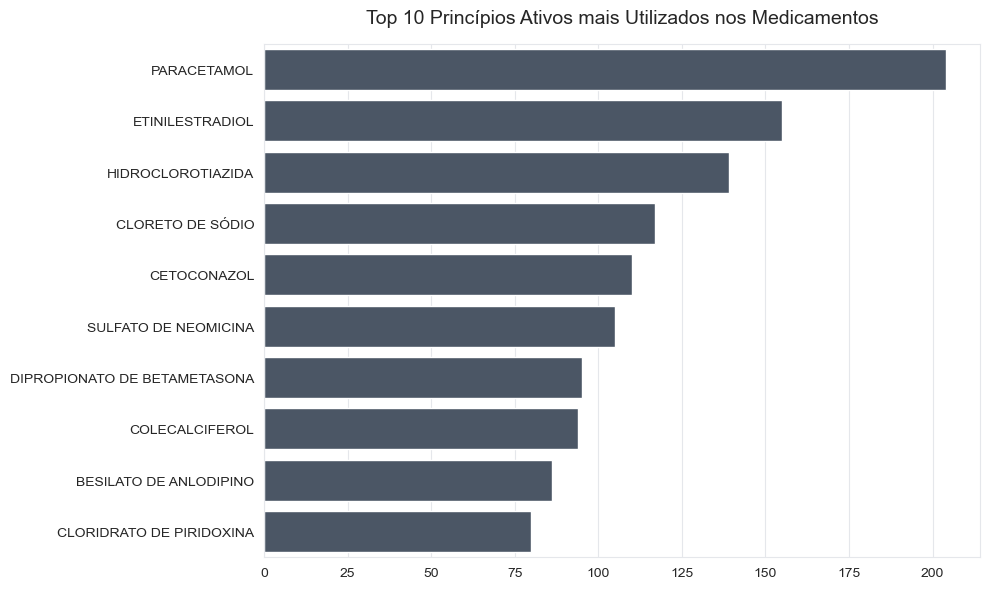

In [65]:
# PERGUNTA: Quais são os princípios ativos mais utilizados? TOP 10

# Conta quantos medicamentos usam cada princípio ativo
df_ai_top10 = (
    df_med_ai['id_active_ingredient']
    .value_counts()
    .head(10)
    .reset_index()
    .rename(columns={'index': 'id_active_ingredient', 'id_active_ingredient': 'Quantidade'})
)

# Concatena o id com o nome
df_ai_top10 = df_ai_top10.merge(
    df_ai[['id_active_ingredient', 'nm_active_ingredient']], 
    on='id_active_ingredient', 
    how='left'
)

# Paleta monocromática azul (escuro no topo → claro embaixo) 
#paleta = sns.light_palette("#003366", n_colors=len(df_ai_top10), reverse=True) 
paleta = sns.light_palette("#4D4D4D", n_colors=len(df_ai_top10), reverse=True) 
#paleta = sns.light_palette("#1F4E79", n_colors=len(df_ai_top10), reverse=True)

# Visualização
plt.figure(figsize=(10, 6))
ax = sns.barplot(  # <- capture o Axes
    data=df_ai_top10,
    x='Quantidade',
    y='nm_active_ingredient',
    color='#475569'
    #color = 'darkgray'
    #palette=paleta
)



# Estilo das linhas internas e do contorno externo
GRID_COLOR = '#E5E7EB'  # cinza claro
GRID_LW    = 0.8        # estreito
GRID_LS    = '-'        # linha contínua

# Grid interno por cima das barras
ax.set_axisbelow(True)
ax.xaxis.grid(True, which='major', linestyle=GRID_LS, linewidth=GRID_LW, color=GRID_COLOR, zorder=4)

# Contorno externo (mesmo estilo do grid)
for side in ['left', 'right', 'top', 'bottom']:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linestyle(GRID_LS)
    ax.spines[side].set_linewidth(GRID_LW)
    ax.spines[side].set_color(GRID_COLOR)

plt.title('Top 10 Princípios Ativos mais Utilizados nos Medicamentos', fontsize=14, pad=15)
plt.ylabel('')
plt.xlabel('')

plt.tight_layout()
plt.show()


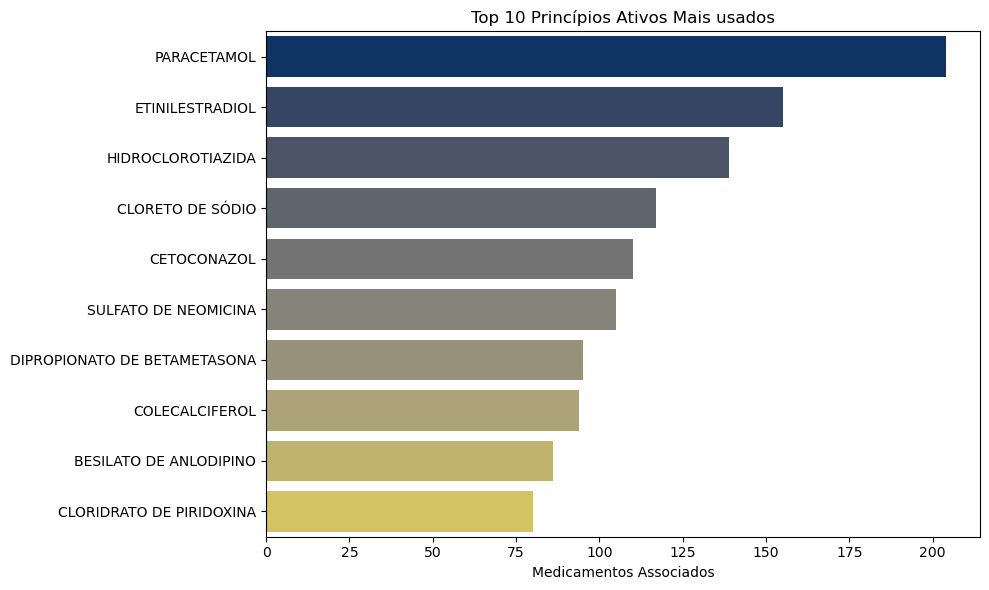

In [19]:
# QUESTION: What are the most used active ingredients? TOP 10

# How many medications contain each active ingredient?
df_ai_top10 = (
    df_med_ai['id_active_ingredient']
    .value_counts()
    .head(10)
    .reset_index()
    .rename(columns={'index': 'id_active_ingredient', 'id_active_ingredient': 'Amount'})
)

# Concat id with name
df_ai_top10 = df_ai_top10.merge(df_ai[['id_active_ingredient', 'nm_active_ingredient']], on='id_active_ingredient',
                                how='left')
# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=df_ai_top10, x='Amount', y='nm_active_ingredient', palette='cividis')
plt.title('Top 10 Princípios Ativos Mais usados')
plt.xlabel('Medicamentos Associados')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [20]:
# PERGUNTA: Quais são os princípios ativos que estão presentes no maior número de medicamentos, 
#           em ordem decrescente de ocorrência?

# Conta quantos medicamentos estão associados a cada princípio ativo
# Apresenta as possibilidades de reuso dos princípios ativos e a 
# frequência de uso da lista COMPLETA dos princípios ativos do Healdb

df_ai_counts = (
    df_med_ai['id_active_ingredient']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'id_active_ingredient', 'id_active_ingredient': 'Quantidade Medicamentos'})
)

# Filtra os que aparecem em mais de 1 medicamento
df_ai_multiplos = df_ai_counts[df_ai_counts['Quantidade Medicamentos'] > 1]

# Merge com nomes
df_ai_multiplos = df_ai_multiplos.merge(
    df_med_ai[['id_active_ingredient', 'nm_active_ingredient']].drop_duplicates(),
    on='id_active_ingredient',
    how='left'
)

# Seleciona os primeiros 30 registros
df_ai_multiplos = df_ai_multiplos.head(30)

# Renomer colunas e reordena
df_ai_multiplos = df_ai_multiplos.rename(columns={
    'id_active_ingredient': 'Id Princípio Ativo',
    'nm_active_ingredient': 'Princípio Ativo'
})[["Id Princípio Ativo", "Quantidade Medicamentos", "Princípio Ativo"]]

styled_table = df_ai_multiplos.style.set_table_styles(
    [
        {'selector': 'th', 'props': [('text-align', 'left')]},  
        {'selector': 'td', 'props': [('text-align', 'left')]}   
    ]
).hide(axis="index")  

print ("\nQuantidade de medicamentos que contêm determinado Princípio Ativo:")

display(styled_table)


Quantidade de medicamentos que contêm determinado Princípio Ativo:


Id Princípio Ativo,Quantidade Medicamentos,Princípio Ativo
139,204,PARACETAMOL
35,155,ETINILESTRADIOL
156,139,HIDROCLOROTIAZIDA
444,117,CLORETO DE SÓDIO
471,110,CETOCONAZOL
38,105,SULFATO DE NEOMICINA
465,95,DIPROPIONATO DE BETAMETASONA
71,94,COLECALCIFEROL
32,86,BESILATO DE ANLODIPINO
322,80,CLORIDRATO DE PIRIDOXINA


In [21]:
# PERGUNTA: Quais medicamentos existentes contêm um determinado princípio ativo?

# Solicita o nome (ou parte) do princípio ativo
active_ing = input("Digite o nome do princípio ativo (ou parte dele): ").strip().upper()

df_nome_ai = df_med_ai[df_med_ai['nm_active_ingredient'].str.contains(active_ing, case=False)]
# Seleciona os IDs desses princípios ativos
ids = df_nome_ai['id_active_ingredient'].tolist()

# Busca medicamentos que contenham esses princípios ativos
df_filtrados = df_med_ai[df_med_ai['id_active_ingredient'].isin(ids)]
df_resultado = df_filtrados.merge(df_med[['id_medication', 'nm_medication']], on='id_medication', how='left')

df_resultado = df_resultado.drop(columns=['nm_medication_y'])

# Seleciona os primeiros 30 registros
df_resultado = df_resultado.head(30)

df_resultado = df_resultado.rename(columns={
    'id_medication': 'Id Medicamento',
    'nm_medication_x': 'Medicamento',
    'nm_company': 'Empresa',
    'id_active_ingredient': 'Id Princípio Ativo',
    'nm_active_ingredient': 'Princípio Ativo',
    'nm_active_ingredient_eng': 'Princípio Ativo Inglês'
})
styled_table = df_resultado.style.set_table_styles(
    [
        {'selector': 'th', 'props': [('text-align', 'left')]},  
        {'selector': 'td', 'props': [('text-align', 'left')]}   
    ]
).hide(axis="index") 
print (f"\nMedicamentos que possuem o princípio ativo {active_ing}:")
display(styled_table)

# EXEMPLOS QUE PODEM SER USADOS PARA TESTE:
# - LORATADINA
# - ÁCIDO ACETILSALICÍLICO
# - ÁCIDO ASCÓRBICO
# - HIDROXICLOROQUINA
# - LINEZOLIDA
# - DEXTRANA
# - HIDROXOCOBALAMINA
# - DESONIDA
# - PARACETAMOL

Digite o nome do princípio ativo (ou parte dele): loratadina

Medicamentos que possuem o princípio ativo LORATADINA:


Id Medicamento,Medicamento,Empresa,Id Princípio Ativo,Princípio Ativo,Princípio Ativo Inglês
213,ALERADINA,GERMED FARMACEUTICA LTDA,168,DESLORATADINA,DESLORATADINE
257,ALOFF,EUROFARMA LABORATÓRIOS S.A.,168,DESLORATADINA,DESLORATADINE
258,ALOFF XPE,EUROFARMA LABORATÓRIOS S.A.,168,DESLORATADINA,DESLORATADINE
562,AVIANT,ORGANON FARMACÊUTICA LTDA.,168,DESLORATADINA,DESLORATADINE
563,AVIANT EFE,ORGANON FARMACÊUTICA LTDA.,168,DESLORATADINA,DESLORATADINE
2258,DESALEX,ORGANON FARMACÊUTICA LTDA.,168,DESLORATADINA,DESLORATADINE
2259,DESALEX D12,ORGANON FARMACÊUTICA LTDA.,168,DESLORATADINA,DESLORATADINE
2267,DESLIN,ZYDUS NIKKHO FARMACÊUTICA LTDA,168,DESLORATADINA,DESLORATADINE
2268,DESLORANA,LEGRAND PHARMA INDÚSTRIA FARMACÊUTICA LTDA,168,DESLORATADINA,DESLORATADINE
2269,DESLORATADINA,PRATI DONADUZZI & CIA LTDA,168,DESLORATADINA,DESLORATADINE


## 3. Medicamentos e doenças

**Perguntas:**
- Quais doenças têm mais medicamentos associados? TOP 15
- Quais medicamentos são mais versáteis (tratam mais doenças)?
- Quais princípios ativos são mais versáteis (tratam mais doenças)?
- Quais são os scores médios por categoria CID?
- Para uma doença específica, quais são os medicamentos associados e seus scores? (ex: L61)
- Qual a distribuição do score de associação entre o medicamento e a doença? 

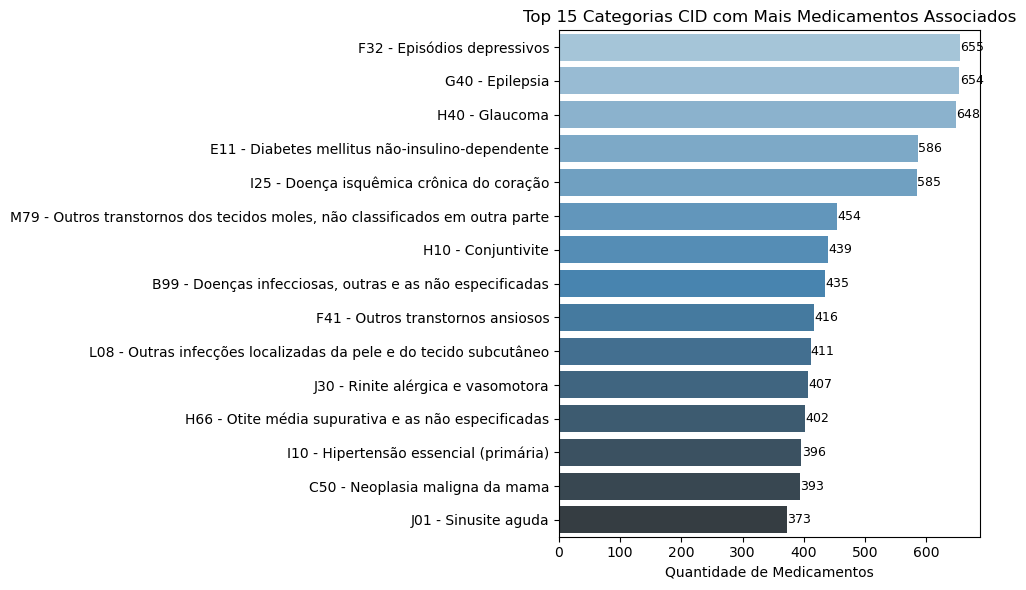

In [22]:
# PERGUNTA: Quais doenças têm mais medicamentos associados? TOP 15

# Agrupa por código da categoria (cd_cat) e traz a descrição
df_top_cat = (
    df_med_disease[df_med_disease['cd_cat'].notna()]
    .groupby(['cd_cat', 'ds_cat'])
    .size()
    .reset_index(name='Qtd_Medicamentos')
    .sort_values(by='Qtd_Medicamentos', ascending=False)
    .head(15)
)

# Concatena o código com o nome
df_top_cat['Doença'] = df_top_cat['cd_cat'] + ' - ' + df_top_cat['ds_cat']

# Visualização
plt.figure(figsize=(10, 6))
bars = sns.barplot(data=df_top_cat, y='Doença', x='Qtd_Medicamentos', palette='Blues_d')

for bar in bars.patches:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height() / 2, 
             f'{int(width)}', va='center', 
             ha='left', fontsize=9)

plt.title('Top 15 Categorias CID com Mais Medicamentos Associados')
plt.xlabel('Quantidade de Medicamentos')
plt.ylabel('')
plt.tight_layout()
plt.show()


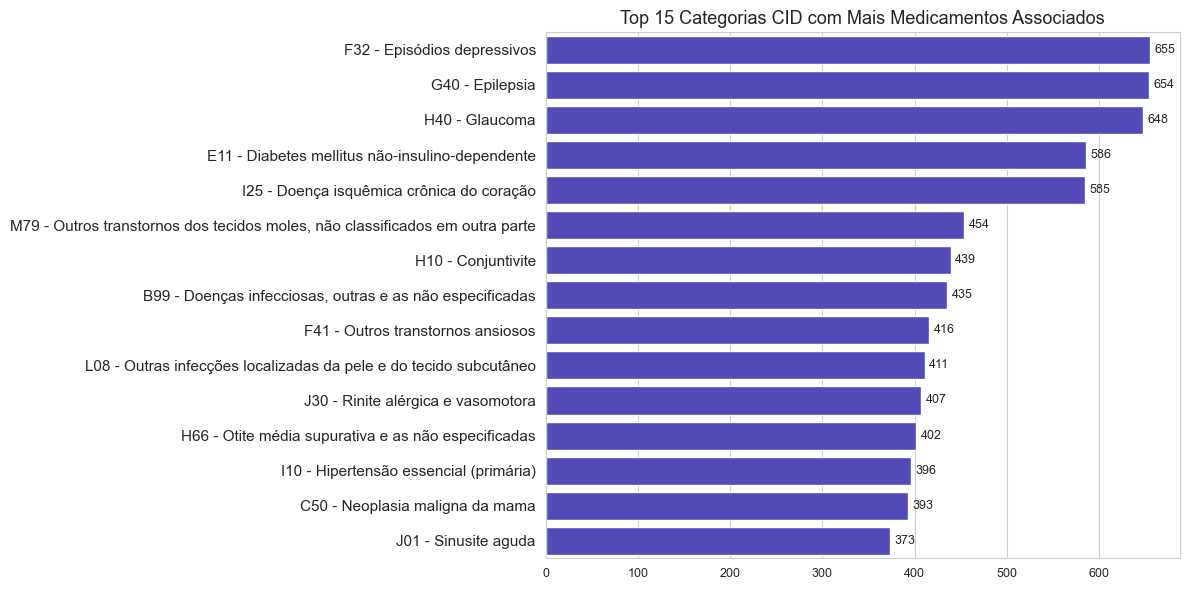

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar dados (igual antes)
df_top_cat = (
    df_med_disease[df_med_disease['cd_cat'].notna()]
    .groupby(['cd_cat', 'ds_cat'])
    .size()
    .reset_index(name='Qtd_Medicamentos')
    .sort_values(by='Qtd_Medicamentos', ascending=False)
    .head(15)
)

# Concatena código + descrição
df_top_cat['rotulo'] = df_top_cat['cd_cat'] + ' - ' + df_top_cat['ds_cat']

# Plot
plt.figure(figsize=(12, 6))  # largura maior para dar respiro
sns.set_style("whitegrid")

bars = sns.barplot(
    data=df_top_cat,
    y='rotulo',
    x='Qtd_Medicamentos',
    #palette='Blues_d',
    color='#4338CA'
    color='#4338CA'
)

# Adiciona valores
for bar in bars.patches:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}',
             va='center', ha='left', fontsize=9)

# Ajustes
plt.title('Top 15 Categorias CID com Mais Medicamentos Associados', fontsize=13)
#plt.xlabel('Quantidade de Medicamentos', fontsize=11)
plt.xlabel('')
plt.ylabel('')

plt.xticks(fontsize=9)   # eixo X menor
plt.yticks(fontsize=11)  # eixo Y maior (lado esquerdo)

plt.tight_layout()
plt.show()

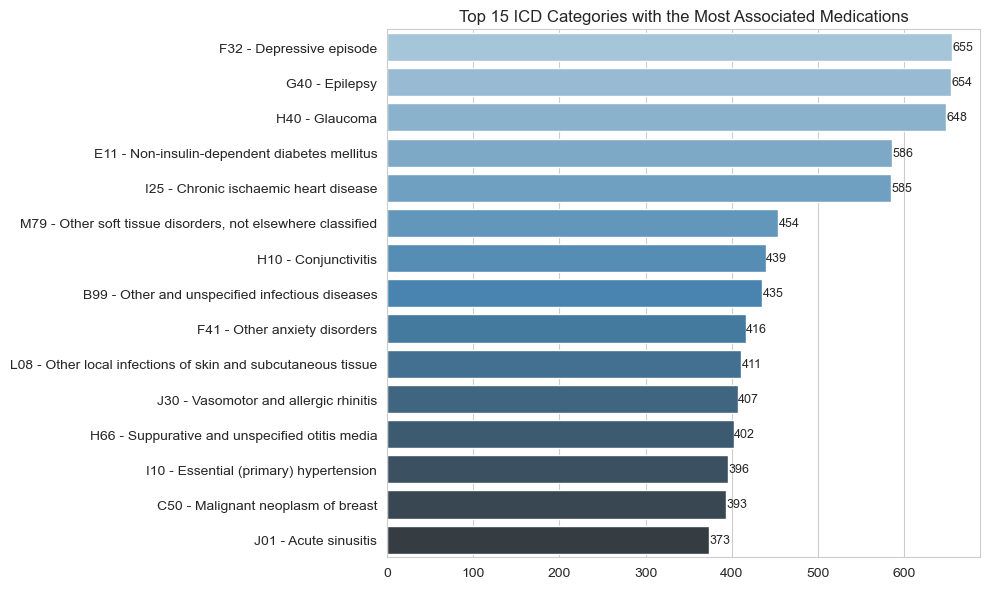

In [57]:
# PERGUNTA: What are the ICD Categories with the most associated medications? TOP 15

# Group by icd cotegory code (cd_cat) and search the description
df_top_cat = (
    df_med_disease[df_med_disease['cd_cat'].notna()]
    .groupby(['cd_cat', 'ds_cat', 'ds_cat_eng'])
    .size()
    .reset_index(name='Qtd_Medications')
    .sort_values(by='Qtd_Medications', ascending=False)
    .head(15)
)

# Concat code and category description
df_top_cat['Disease'] = df_top_cat['cd_cat'] + ' - ' + df_top_cat['ds_cat_eng']

# Visualization
plt.figure(figsize=(10, 6))

bars = sns.barplot(data=df_top_cat, y='Disease', x='Qtd_Medications', palette='Blues_d')

for bar in bars.patches:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height() / 2, 
             f'{int(width)}', va='center', 
             ha='left', fontsize=9)

plt.title('Top 15 ICD Categories with the Most Associated Medications')
#plt.xlabel('Number of Medications')

plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()


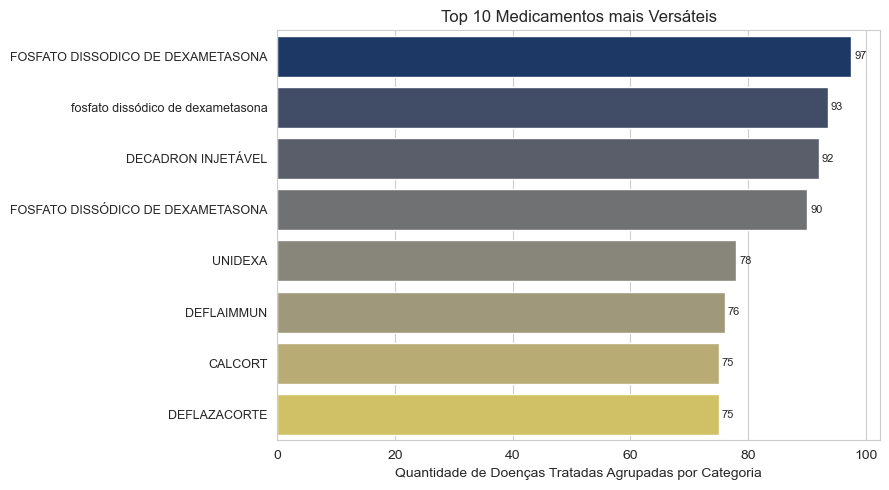

In [25]:
# PERGUNTA: Quais medicamentos são mais versáteis (tratam mais doenças)?

# Qtde de doenças únicas por medicamento
df_versatilidade = (
    #df_med_disease.groupby(['id_medication', 'nm_medication'])['cd_icd_full']
    df_med_disease.groupby(['id_medication', 'nm_medication'])['cd_cat']
    .nunique()
    .reset_index(name='qt_doencas')
    .sort_values(by='qt_doencas', ascending=False)
)
# Renomeia as colunas 
df_versatilidade_2 = df_versatilidade.rename(columns={
    'id_medication': 'Id Medicamento',
    'nm_medication': 'Medicamento',
    'qt_doencas': 'Qtd Doenças'
})

# Exibe os 10 medicamentos mais versáteis como tabela formatada
styled_table = df_versatilidade_2.head(10).style.set_table_styles(
    [
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ]
).hide(axis="index")

#display(styled_table)

df_top_versatil = df_versatilidade.head(10).sort_values(by='qt_doencas', ascending=False)  # ordena para barras horizontais

plt.figure(figsize=(9, 5))
bars = sns.barplot(data=df_top_versatil, y='nm_medication', 
                   x='qt_doencas', palette='cividis', errorbar=None)

for bar in bars.patches:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        ha='left',
        fontsize=8
    )

bars.set_yticklabels(bars.get_yticklabels(), fontsize=9)
plt.ylabel('')  
plt.title('Top 10 Medicamentos mais Versáteis')
plt.xlabel('Quantidade de Doenças Tratadas Agrupadas por Categoria')
plt.tight_layout()
plt.show()


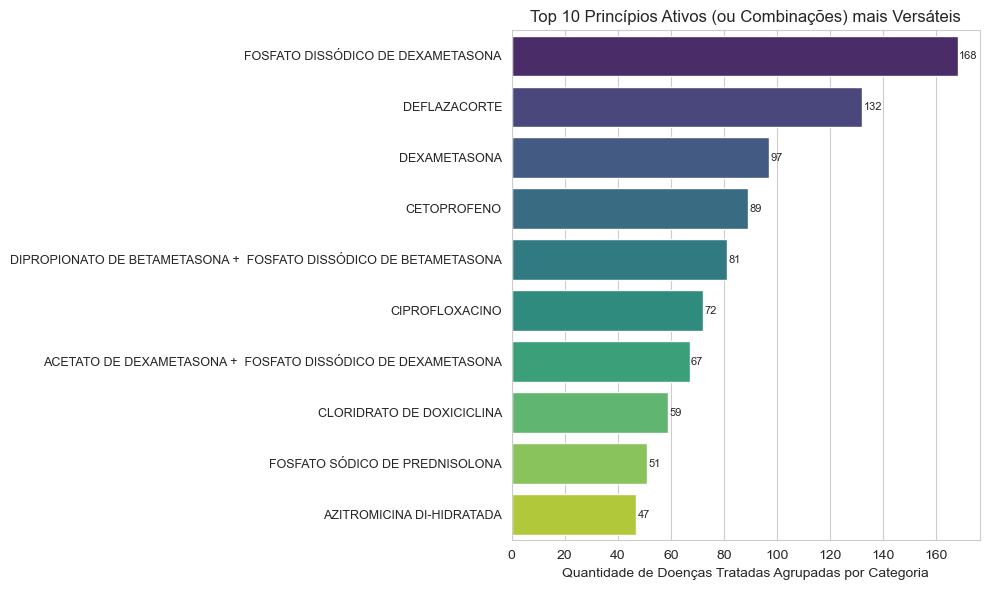

In [26]:
# PERGUNTA: Quais princípios ativos são mais versáteis (tratam mais doenças)?

# Conta quantas doenças únicas cada princípio ativo ou grupo de princípios ativos tratam
df_versatilidade = (
    df_med_disease.groupby(['ds_active_ingredients'])['cd_cat']
    .nunique()
    .reset_index(name='qt_doencas')
    .sort_values(by='qt_doencas', ascending=False)
)

# Renomeia as colunas 
df_versatilidade_2 = df_versatilidade.rename(columns={
    'ds_active_ingredients': 'Princípios Ativos',
    'qt_doencas': 'Qtd Doenças'
})
# Exibe os 10 princípios ativos ou grupos de princípios ativos mais versáteis como tabela formatada
styled_table = df_versatilidade_2.head(10).style.set_table_styles(
    [
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ]
).hide(axis="index")

#display(styled_table)

df_top_versatil = df_versatilidade.head(10).sort_values(by='qt_doencas', ascending=False)  # ordena para barras horizontais

plt.figure(figsize=(10, 6))
bars = sns.barplot(data=df_top_versatil, y='ds_active_ingredients', 
                   x='qt_doencas', palette='viridis', errorbar=None)

for bar in bars.patches:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        ha='left',
        fontsize=8
    )

bars.set_yticklabels(bars.get_yticklabels(), fontsize=9)
plt.ylabel('')  # remove o ds_active_ingredients

plt.title('Top 10 Princípios Ativos (ou Combinações) mais Versáteis')
plt.xlabel('Quantidade de Doenças Tratadas Agrupadas por Categoria')
plt.tight_layout()
plt.show()

In [27]:
# PERGUNTA: Quais são os scores médios por categoria CID?

# Score médio por categoria CID
df_score_grupo = (
    df_med_disease.groupby(['cd_cat', 'ds_cat'])['vl_score']
    .mean()
    .reset_index(name='vl_score_medio')
    .sort_values(by='vl_score_medio', ascending=False)
)

df_score_grupo = df_score_grupo.rename(columns={
    'cd_cat': 'CID',
    'ds_cat': 'Categoria',
    'vl_score_medio':'Score Medio'
})
# Exibe 20 categorias de doenças e a média de seus respectivos scores
styled_table = df_score_grupo.head(20).style.set_table_styles(
    [
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ]
).hide(axis="index")

print ("\n Score Médio das doenças associadas aos medicamentos por categoria CID:")
display(styled_table)




 Score Médio das doenças associadas aos medicamentos por categoria CID:


CID,Categoria,Score Medio
J80,Síndrome do desconforto respiratório do adulto,0.979067
L80,Vitiligo,0.965819
L57,Alterações da pele devidas à exposição crônica à radiação não ionizante,0.952678
L26,Dermatite esfoliativa,0.936052
N47,"Hipertrofia do prepúcio, fimose e parafimose",0.935206
R64,Caquexia,0.932982
J90,Derrame pleural não classificado em outra parte,0.926523
F40,Transtornos fóbico-ansiosos,0.926498
R79,Outros achados anormais de exames químicos do sangue,0.926244
A78,Febre Q,0.924584


In [28]:
# PERGUNTA: Para uma doença específica, quais são os medicamentos associados e seus scores? (ex: L61)

# Input do usuário
cid_input = input("Digite o código CID (ex: F41 ou L21.0): ").strip().upper().replace('.', '')

if len(cid_input) <= 3:
    # Busca em categoria
    df_cid = df_med_disease[df_med_disease['cd_cat'] == cid_input]
    if not df_cid.empty:
        ds_cat = df_cid['ds_cat'].iloc[0]
        print(f"Categoria CID {cid_input} - {ds_cat}")

    else:
        print(f"\n Nenhuma associação encontrada para a categoria CID {cid_input}")
else:
    # Busca em subcategoria
    df_cid = df_med_disease[df_med_disease['cd_subcat'] == cid_input]
    if not df_cid.empty:
        ds_subcat = df_cid['ds_subcat'].iloc[0]
        print(f"\n Subcategoria CID {cid_input} - {ds_subcat}")
    else:
        print(f"\n Nenhuma associação encontrada para a subcategoria CID {cid_input}")

# Exibe os medicamentos associados se houver
if not df_cid.empty:
    df_resultado = df_cid[['id_medication', 'nm_medication', 'nm_company', 'vl_score']].sort_values(by='vl_score', ascending=False)
    # Renomeia as colunas 
    df_resultado = df_resultado.rename(columns={
        'id_medication': 'Id Medicamento',
        'nm_medication': 'Medicamento',
        'nm_company': 'Empresa',
        'vl_score':'Score'
    })
    # Exibe os 10 princípios ativos ou grupos de princípios ativos mais versáteis 
    styled_table = df_resultado.head(20).style.set_table_styles(
        [
            {'selector': 'th', 'props': [('text-align', 'left')]},
            {'selector': 'td', 'props': [('text-align', 'left')]}
        ]
    ).hide(axis="index")
    print (f"\n Medicamentos indicados para a doença cujo CID é {cid_input} - {ds_cat}:")
    display(styled_table)
    
# EXEMPLOS DE CIDS QUE PODEM SER 

# - C61 Neoplasias malignas dos órgãos genitais masculinos
# - L21 Dermatite seborréica
# - I21 Infarto agudo do miocárdio
# - I10 Doenças hipertensivas
# - M54 Dorsalgia
# - E51 Deficiência de tiamina
# - H40 Glaucoma
# - G70 Miastenia gravis e outros transtornos neuromusculares


Digite o código CID (ex: F41 ou L21.0): L21
Categoria CID L21 - Dermatite seborréica

 Medicamentos indicados para a doença cujo CID é L21 - Dermatite seborréica:


Id Medicamento,Medicamento,Empresa,Score
2299,DEXAGREEN,GREENPHARMA QUÍMICA E FARMACÊUTICA LTDA,0.974765
2296,DEXADERMIL,LEGRAND PHARMA INDÚSTRIA FARMACÊUTICA LTDA,0.972243
2188,DECADRON INJETÁVEL,ACHÉ LABORATÓRIOS FARMACÊUTICOS S.A,0.963281
8763,fosfato dissódico de dexametasona,FARMACE INDÚSTRIA QUÍMICO-FARMACÊUTICA CEARENSE LTDA,0.961547
2200,DEFLAIMMUN,EMS SIGMA PHARMA LTDA,0.960695
8543,clotrimazol,BELFAR LTDA,0.958480
7607,Valerato Betametasona,GERMED FARMACEUTICA LTDA,0.955032
2312,DEXASON,LABORATÓRIO TEUTO BRASILEIRO S/A,0.953956
2244,DERMOBENE,LEGRAND PHARMA INDÚSTRIA FARMACÊUTICA LTDA,0.952656
1134,CANESTEN,BAYER S.A.,0.952126


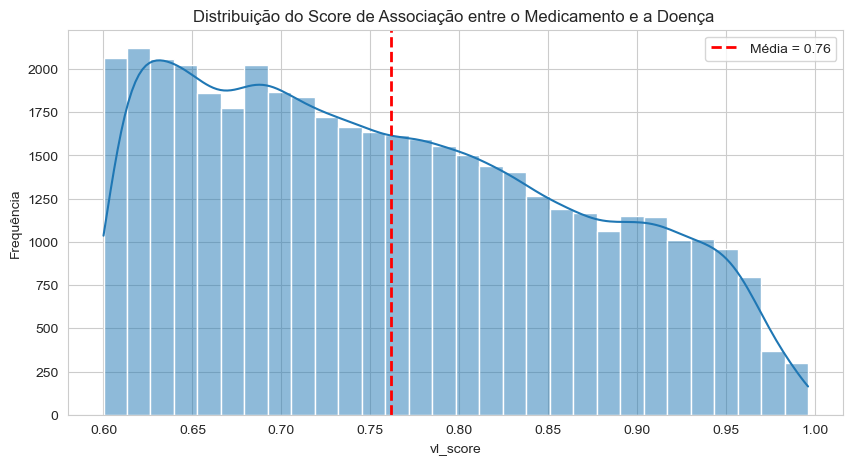

In [29]:
# PERGUNTA: Qual a distribuição do score de associação entre o medicamento e a doença? 

# Distribuição de scores

# Calcula a média do vl_score e cria o histograma
mean_score = df_med_disease['vl_score'].mean()
plt.figure(figsize=(10, 5))
sns.histplot(df_med_disease['vl_score'], bins=30, kde=True) # Inclusão do KDE (Kernel Density Estimate) - distribuição de probabilidade contínua dos dados

# Adiciona linha vertical na média do vl_score
plt.axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Média = {mean_score:.2f}')

plt.title("Distribuição do Score de Associação entre o Medicamento e a Doença ")
plt.xlabel("vl_score")
plt.ylabel("Frequência")
plt.legend()

plt.show()


## 4. Interações Medicamentosas e de Alimentos

**Perguntas:**
- Existem interações medicamentosas entre dois princípios ativos específicos? Quais são elas?
- Quais as interações medicamentosas de um determinado medicamento?
- Um determinado medicamento possui interações com alimentos?
- Quais são os TOP 20 princípios ativos que apresentam o maior número de interações medicamentosas, em ordem decrescente de frequência?

In [30]:
# PERGUNTA: Existem interações medicamentosas entre dois princípios ativos específicos? Quais são elas?

# Input do usuário
ai_input1 = input("Digite o Princípio ativo 1: ").strip().upper()
ai_input2 = input("Digite o Princípio ativo 2: ").strip().upper()

# Aplica filtro com contains para simular o LIKE '%...%'
df_resultado = df_drug_int[
    df_drug_int['nm_active_ingredient'].str.upper().str.contains(ai_input1) &
    df_drug_int['nm_active_ingredient2'].str.upper().str.contains(ai_input2)
]

# Exibe resultados
if not df_resultado.empty:
    df_resultado = df_resultado[[
        'nm_active_ingredient', 
        'nm_active_ingredient2',
        'ds_drug_interaction_port', 
        'ds_drug_interaction_eng'
    ]].rename(columns={
        'nm_active_ingredient': 'Princípio Ativo 1',
        'nm_active_ingredient2': 'Princípio Ativo 2',
        'ds_drug_interaction_port': 'Interação (Português)',
        'ds_drug_interaction_eng': 'Interação (Inglês)'
    })

    print(f"\nInterações medicamentosas entre '{ai_input1}' e '{ai_input2}':\n")
    styled_table = df_resultado.style.set_table_styles(
        [
            {'selector': 'th', 'props': [('text-align', 'left')]},
            {'selector': 'td', 'props': [('text-align', 'left')]}
        ]
    ).hide(axis="index")
    display(styled_table)

else:
    print(f"\n Nenhuma interação medicamentosa encontrada entre '{ai_input1}' e '{ai_input2}'.")

# Exemplos de alguns testes que podem ser feitos: 
# - DIGOXINA e DIAZEPAM
# - CLOROQUINA e AZITROMICINA
# - ALPRAZOLAM e CIMETIDINA
# - DIAZEPAM e TRIAZOLAM
# - AMOXICILINA e ACICLOVIR
# - OMEPRAZOL e CLOPIDOGREL
# - ACIDO ACETILSALICILICO (AAS) e CAPTOPRIL
# - VARFARINA e CLOPIDOGREL
# - DIAZEPAM e CIMETIDINA
# - ÁCIDO ASCÓRBICO e TIBOLONA
# - ÁCIDO ASCÓRBICO e PROMESTRIENO
# - ÁCIDO ASCÓRBICO e ESTRADIOL

Digite o Princípio ativo 1: AMOXICILINA
Digite o Princípio ativo 2: ACICLOVIR

Interações medicamentosas entre 'AMOXICILINA' e 'ACICLOVIR':



Princípio Ativo 1,Princípio Ativo 2,Interação (Português),Interação (Inglês)
AMOXICILINA TRI-HIDRATADA,CLORIDRATO DE VALACICLOVIR,"Cloridrato de valaciclovir pode diminuir a taxa de excreção de Amoxicilina tri-hidratada, o que poderia resultar em um nível sérico mais elevado.",Valaciclovir may decrease the excretion rate of Amoxicillin which could result in a higher serum level.
AMOXICILINA TRIHIDRATADA,CLORIDRATO DE VALACICLOVIR,"Cloridrato de valaciclovir pode diminuir a taxa de excreção de Amoxicilina tri-hidratada, o que poderia resultar em um nível sérico mais elevado.",Valaciclovir may decrease the excretion rate of Amoxicillin which could result in a higher serum level.
AMOXICILINA,CLORIDRATO DE VALACICLOVIR,"Cloridrato de valaciclovir pode diminuir a taxa de excreção de Amoxicilina tri-hidratada, o que poderia resultar em um nível sérico mais elevado.",Valaciclovir may decrease the excretion rate of Amoxicillin which could result in a higher serum level.
AMOXICILINA SÓDICA,CLORIDRATO DE VALACICLOVIR,"Cloridrato de valaciclovir pode diminuir a taxa de excreção de Amoxicilina tri-hidratada, o que poderia resultar em um nível sérico mais elevado.",Valaciclovir may decrease the excretion rate of Amoxicillin which could result in a higher serum level.
AMOXICILINA TRI-HIDRATADA,ACICLOVIR,"Aciclovir pode diminuir a taxa de excreção de Amoxicilina tri-hidratada, o que poderia resultar em um nível sérico mais elevado.",Acyclovir may decrease the excretion rate of Amoxicillin which could result in a higher serum level.
AMOXICILINA TRI-HIDRATADA,ACICLOVIR SÓDICO,"Aciclovir pode diminuir a taxa de excreção de Amoxicilina tri-hidratada, o que poderia resultar em um nível sérico mais elevado.",Acyclovir may decrease the excretion rate of Amoxicillin which could result in a higher serum level.
AMOXICILINA TRIHIDRATADA,ACICLOVIR,"Aciclovir pode diminuir a taxa de excreção de Amoxicilina tri-hidratada, o que poderia resultar em um nível sérico mais elevado.",Acyclovir may decrease the excretion rate of Amoxicillin which could result in a higher serum level.
AMOXICILINA TRIHIDRATADA,ACICLOVIR SÓDICO,"Aciclovir pode diminuir a taxa de excreção de Amoxicilina tri-hidratada, o que poderia resultar em um nível sérico mais elevado.",Acyclovir may decrease the excretion rate of Amoxicillin which could result in a higher serum level.
AMOXICILINA,ACICLOVIR,"Aciclovir pode diminuir a taxa de excreção de Amoxicilina tri-hidratada, o que poderia resultar em um nível sérico mais elevado.",Acyclovir may decrease the excretion rate of Amoxicillin which could result in a higher serum level.
AMOXICILINA,ACICLOVIR SÓDICO,"Aciclovir pode diminuir a taxa de excreção de Amoxicilina tri-hidratada, o que poderia resultar em um nível sérico mais elevado.",Acyclovir may decrease the excretion rate of Amoxicillin which could result in a higher serum level.


In [31]:
# PERGUNTA: Quais as interações medicamentosas de um determinado medicamento?

# Input: nome do medicamento
med_input = input("Digite o nome do medicamento: ").strip().upper()

# Filtra os princípios ativos do medicamento informado
df_med_ai_filt = df_med_ai[df_med_ai['nm_medication'].str.upper().str.contains(med_input)]

if df_med_ai_filt.empty:
    print(f"Nenhum princípio ativo encontrado para o medicamento: {med_input}")
else:
    # Princípios ativos dos medicamentos
    ids_ai = df_med_ai_filt['id_active_ingredient'].unique().tolist()
    nms_ai = df_med_ai_filt['nm_active_ingredient'].unique().tolist()
    
    print (f"Princípios ativos do medicamento {med_input}: {nms_ai}")

    # Busca interações medicamentosas dos princípios ativos selecionados
    
    df_int = df_drug_int[
        df_drug_int['id_active_ingredient'].isin(ids_ai) | 
        df_drug_int['id_active_ingredient2'].isin(ids_ai)
    ][['nm_active_ingredient', 'ds_drug_interaction_port']].drop_duplicates()

    # Exibe o resultado 
    if df_int.empty:
        print(f"Nenhuma interação medicamentosa encontrada para o medicamento: {med_input}")
    else:
        df_int = df_int.rename(columns={
            'nm_active_ingredient': 'Princípio Ativo',
            'ds_drug_interaction_port': 'Descrição da Interação'
        })

        styled_table = df_int.head(30).style.set_table_styles(
            [
                {'selector': 'th', 'props': [('text-align', 'left')]},
                {'selector': 'td', 'props': [('text-align', 'left'), ('white-space', 'normal'), ('max-width', '500px')]}
            ]
        ).hide(axis="index")
    
        print(f"\nInterações medicamentosas para o medicamento '{med_input}':")
        display(styled_table)
        
# Exemplos de alguns testes que podem ser feitos: 
# - APRACUR
# - AMOXICILINA
# - ARICILINA
# - BENZETACIL
# - REUQUINOL


Digite o nome do medicamento: APRACUr
Princípios ativos do medicamento APRACUR: ['DIPIRONA', 'ÁCIDO ASCÓRBICO', 'DIPIRONA MONOIDRATADA', 'CAFEÍNA', 'MALEATO DE CLORFENIRAMINA']

Interações medicamentosas para o medicamento 'APRACUR':


Princípio Ativo,Descrição da Interação
ETANERCEPTE,O metabolismo do Cafeína pode ser aumentado quando combinado com Etanercepte.
ETANERCEPTE (TNFR:FC),O metabolismo do Cafeína pode ser aumentado quando combinado com Etanercepte.
ETANERCEPTE,O metabolismo do Maleato de clorfeniramina pode ser aumentado quando combinado com Etanercepte.
ETANERCEPTE (TNFR:FC),O metabolismo do Maleato de clorfeniramina pode ser aumentado quando combinado com Etanercepte.
ACETATO DE LEUPRORRELINA,O risco ou a gravidade do prolongamento do intervalo QTc pode ser aumentado quando Acetato de leuprorrelina é combinado com Maleato de clorfeniramina.
ACETATO DE LEUPRORRELINA,"Dipirona pode diminuir a taxa de excreção de Acetato de leuprorrelina, o que poderia resultar em um nível sérico mais elevado."
ALFAPEGINTERFERONA 2A,O risco ou gravidade da mielossupressão pode ser aumentado quando Dipirona é combinado com Alfapeginterferona 2a.
ALFAPEGINTERFERONA 2A,O metabolismo de Cafeína pode ser diminuído quando combinado com Alfapeginterferona 2a.
ACETATO DE GOSSERRELINA,O risco ou a gravidade do prolongamento do intervalo QTc pode ser aumentado quando Acetato de gosserrelina é combinado com Maleato de clorfeniramina.
ACETATO DE GOSSERRELINA,"Dipirona pode diminuir a taxa de excreção de Acetato de gosserrelina, o que poderia resultar em um nível sérico mais elevado."


In [32]:
# PERGUNTA: Um determinado medicamento possui interações com alimentos?

# Input: nome do medicamento
med_input = input("Digite o nome do medicamento: ").strip().upper()

# Filtra os princípios ativos do medicamento informado
df_med_ai_filt = df_med_ai[df_med_ai['nm_medication'].str.upper().str.contains(med_input)]

if df_med_ai_filt.empty:
    print(f"Nenhum princípio ativo encontrado para o medicamento: {med_input}")
else:
    # Lista de IDs dos princípios ativos do medicamento
    ids_ai = df_med_ai_filt['id_active_ingredient'].unique().tolist()
    nms_ai = df_med_ai_filt['nm_active_ingredient'].unique().tolist()

    print(f"Princípios ativos do medicamento {med_input}: {nms_ai}")

    # Busca interações com alimentos desses princípios ativos
    df_food_int_filt = df_food_int[df_food_int['id_active_ingredient'].isin(ids_ai)].drop_duplicates()
    
    # Exibe o resultado 
    if df_food_int_filt.empty:
        print(f"\nNenhuma interação com alimentos encontrada para o medicamento: {med_input}")
    else:
        df_food_int_filt = df_food_int_filt.rename(columns={
            'nm_active_ingredient': 'Princípio Ativo',
            'ds_food_interaction': 'Interação com Alimentos'
        })[['Princípio Ativo', 'Interação com Alimentos']]

        styled_table = df_food_int_filt.head(100).style.set_table_styles(
            [
                {'selector': 'th', 'props': [('text-align', 'left')]},
                {'selector': 'td', 'props': [('text-align', 'left'), ('white-space', 'normal'), ('max-width', '500px')]}
            ]
        ).hide(axis="index")

        print(f"\nInterações com alimentos para o medicamento '{med_input}':")
        display(styled_table)
        
# Exemplos de alguns testes que podem ser feitos: 
# - PENICILINA 
# - ERITROMICINA 
# - TETRACICLINA 
# - FENITOÍNA 


Digite o nome do medicamento: PENICILINA
Princípios ativos do medicamento PENICILINA: ['BENZILPENICILINA POTÁSSICA', 'BENZILPENICILINA PROCAÍNA', 'BENZILPENICILINA BENZATINA', 'FENOXIMETILPENICILINA POTÁSSICA']

Interações com alimentos para o medicamento 'PENICILINA':


Princípio Ativo,Interação com Alimentos
FENOXIMETILPENICILINA POTÁSSICA,Tomar de estômago vazio. A absorção é aumentada 1 hora antes ou 2 horas depois das refeições.


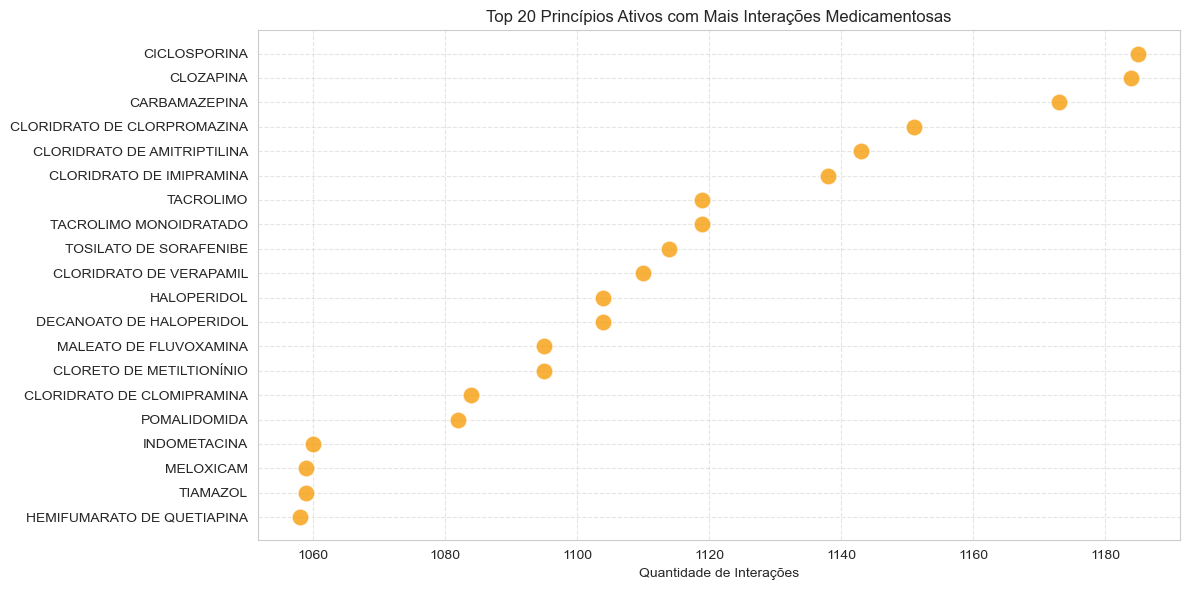

In [52]:
# PERGUNTA: Quais são os TOP 20 princípios ativos que apresentam o maior número de interações medicamentosas, 
#           em ordem decrescente de frequência? 

# Agrupar por princípio ativo e contar o número de interações
df_top_ai_interactions = (
    df_drug_int.groupby(['id_active_ingredient', 'nm_active_ingredient', 'nm_active_ingredient_eng'])
    .size()
    .reset_index(name='Qtd Interações')
    .rename(columns={'nm_active_ingredient': 'Princípio Ativo'})
    .sort_values(by='Qtd Interações', ascending=False)
    .head(20)
)

# Gráfico de Dispersão
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_top_ai_interactions,
    x='Qtd Interações',
    y='Princípio Ativo',
    s=150,
    #color='darkblue',
    color='#F59E0B',
    alpha=0.8
)
plt.title('Top 20 Princípios Ativos com Mais Interações Medicamentosas')
plt.xlabel('Quantidade de Interações')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()








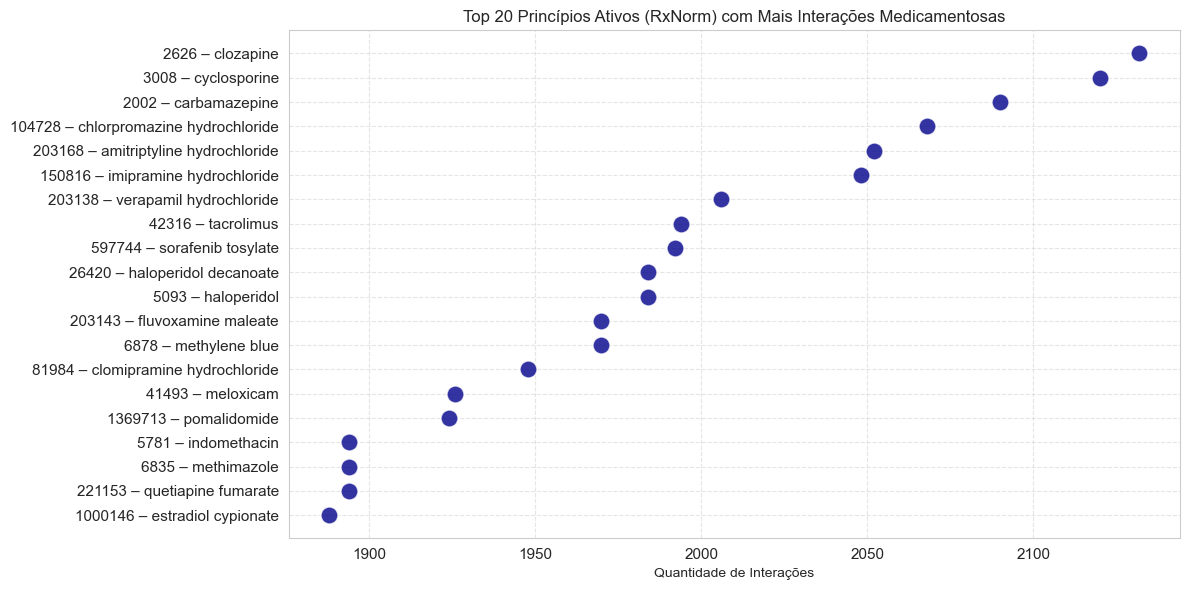

In [34]:
# PERGUNTA: Quais são os TOP 20 princípios ativos normalizados pelo vocabulário do RxNorm (RxCUI) que apresentam o maior 
#           número de interações medicamentosas, em ordem decrescente de frequência? 

# --- RXCUI TOP 20 (gráfico por RXCUI) ---

# 0) Import do projeto (ajuste se necessário)
if r"c:\project\healdb\src" not in sys.path:
    sys.path.append(r"c:\project\healdb\src")

try:
    from interoperability.usecases.rxnorm_export_enriched_ingredients import get_rxcui_properties
    #print("OK: import get_rxcui_properties")
except Exception as e:
    print("ERRO de import get_rxcui_properties:", e)
    get_rxcui_properties = None

# 1) Empilha RXCUIs (das duas colunas) e verifica se há valores
rx_long = pd.concat(
    [
        df_drug_rxcui_int[['rxcui']].rename(columns={'rxcui': 'RXCUI'}),
        df_drug_rxcui_int[['rxcui2']].rename(columns={'rxcui2': 'RXCUI'}),
    ],
    ignore_index=True
)

rx_long = rx_long.dropna()
rx_long['RXCUI'] = rx_long['RXCUI'].astype(str).str.strip()
rx_long = rx_long[rx_long['RXCUI'] != '']

# 2) Top 20 por interações
df_top_rxcui = (
    rx_long.groupby('RXCUI').size().reset_index(name='Qtd Interações')
    .sort_values('Qtd Interações', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# 3) Teste rápido da API em 1 RXCUI (para inspecionar o retorno cru)
def _test_one():
    if get_rxcui_properties is None or df_top_rxcui.empty:
        return None
    sample = str(df_top_rxcui.loc[0, 'RXCUI'])
    try:
        props = get_rxcui_properties(sample)
        #print(f"\nTeste API RxNorm para RXCUI={sample} ->")
        #print(props)  # veja as chaves que vêm (preferred_name? name?)
        return props
    except Exception as e:
        print("Falha ao chamar a API RxNorm:", e)
        return None

_ = _test_one()

# 4) Função defensiva para extrair nome (aceita 'preferred_name' OU 'name' OU 'propName')
_cache = {}
def rxcui_to_name(rxcui, throttle=0.15):
    r = str(rxcui).strip()
    if not r or get_rxcui_properties is None:
        return None
    if r in _cache:
        return _cache[r]
    try:
        props = get_rxcui_properties(r) or {}
        # tente várias chaves possíveis
        name = (
            props.get('preferred_name')
            or props.get('name')
            or props.get('propName')   # caso algum wrapper use essa chave
        )
        _cache[r] = name
        time.sleep(throttle)  # boa prática com API pública
        return name
    except Exception:
        return None

# 5) Enriquecer e checar quantos nomes vieram
df_top_rxcui['Preferred Name'] = df_top_rxcui['RXCUI'].apply(rxcui_to_name)
resolved = df_top_rxcui['Preferred Name'].notna().sum()

# 6) Rótulo para o eixo Y (se não houver nome, cai para o RXCUI)
df_top_rxcui['rotulo'] = df_top_rxcui.apply(
    lambda r: f"{r['RXCUI']} – {r['Preferred Name']}" if pd.notna(r['Preferred Name']) else r['RXCUI'],
    axis=1
)

# 7) Gráfico de bolinhas
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

#Cinza elegante: color="#4D4D4D"
#Cinza médio frio: color="#6B7280"
#Grafite suave: color="#374151"
#Azul médio corporativo: color="#1F4E79"

sns.scatterplot(
    data=df_top_rxcui,
    x='Qtd Interações',
    y='rotulo',
    s=150,          # tamanho das bolinhas
    color='darkblue',  # cor das bolinhas
    alpha=0.8
)

plt.title('Top 20 Princípios Ativos (RxNorm) com Mais Interações Medicamentosas')
plt.xlabel('Quantidade de Interações')
plt.ylabel('')

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

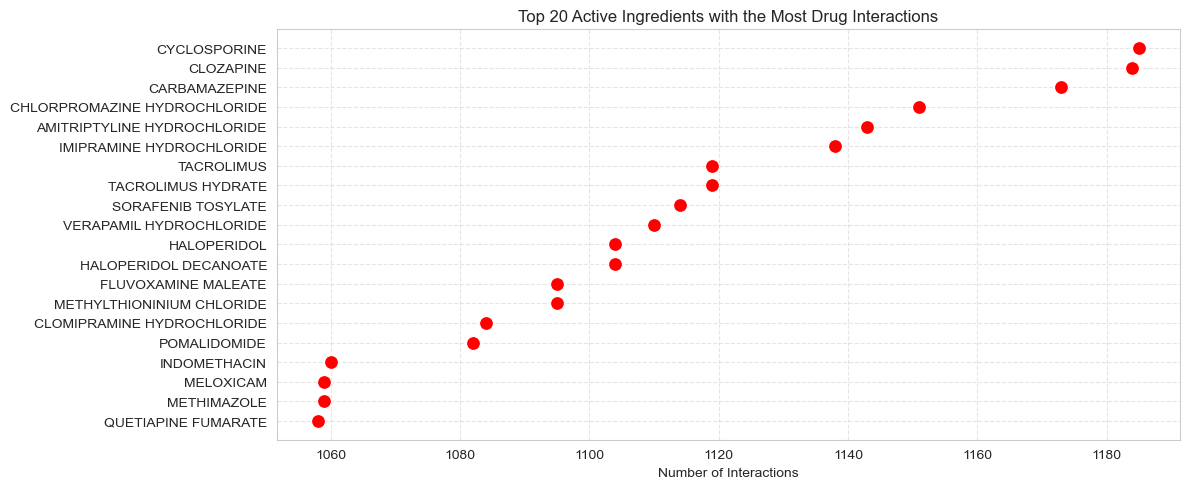

In [115]:
# QUESTION: Which active ingredients have the highest number of drug interactions,
#           in descending order of frequency? TOP 20

# Group by active ingredients and count the number of interactions
df_top_ai_interactions = (
    df_drug_int.groupby(['id_active_ingredient', 'nm_active_ingredient', 'nm_active_ingredient_eng'])
    .size()
    .reset_index(name='Interaction Count')
    .rename(columns={'nm_active_ingredient_eng': 'Active Ingredient'})
    .sort_values(by='Interaction Count', ascending=False)
    .head(20)
)

# Scatterplot graph
plt.figure(figsize=(12, 5))
sns.scatterplot(
    data=df_top_ai_interactions,
    x='Interaction Count',
    y='Active Ingredient',
    s=100,
    color='red'
)
plt.title('Top 20 Active Ingredients with the Most Drug Interactions')
plt.xlabel('Number of Interactions')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

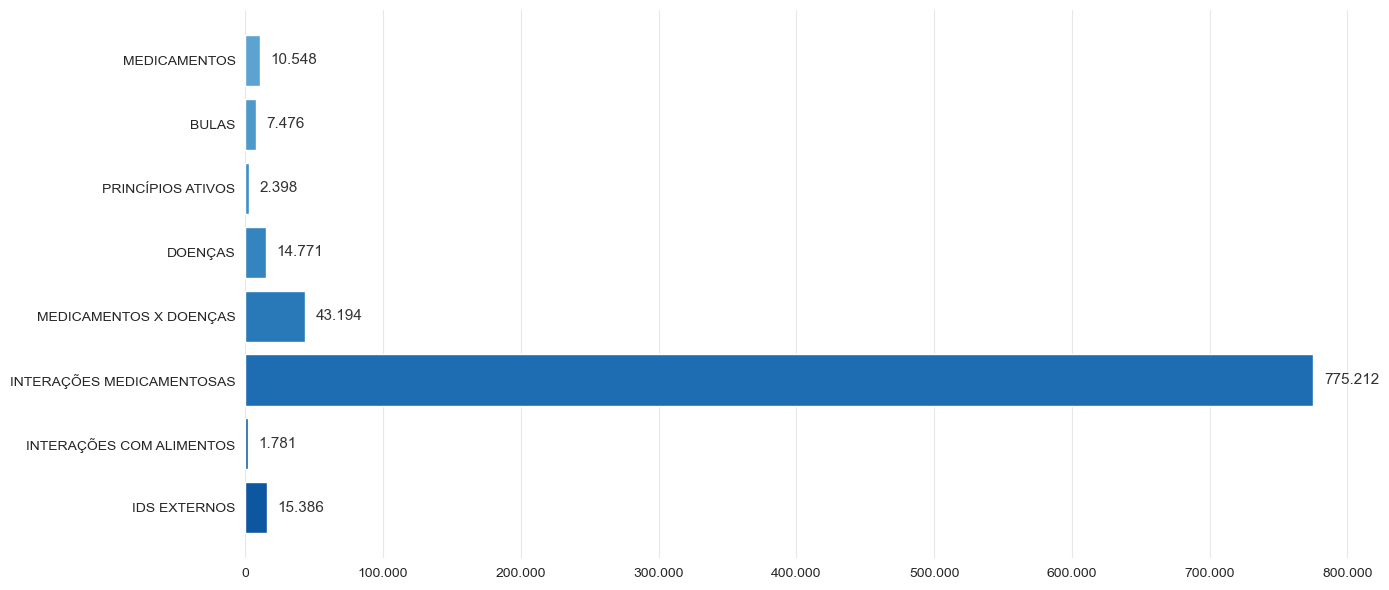

In [121]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# ----- ORDEM FIXA -----
labels = [
    "MEDICAMENTOS",
    "BULAS",
    "PRINCÍPIOS ATIVOS",
    "DOENÇAS",
    "MEDICAMENTOS X DOENÇAS",
    "INTERAÇÕES MEDICAMENTOSAS",
    "INTERAÇÕES COM ALIMENTOS",
    "IDS EXTERNOS",
]

vals_pt = ["10.548", "7.476", "2.398", "14.771", "43.194", "775.212", "1.781", "15.386"]
values = [int(v.replace('.', '')) for v in vals_pt]

# formatador BR: 100000 -> 100.000
fmt_ptbr = lambda x, p=None: f"{int(x):,}".replace(",", ".")
br_fmt = FuncFormatter(fmt_ptbr)

fig, ax = plt.subplots(figsize=(14, 6))

# barras (uma cor ou degrade simples)
colors = plt.cm.Blues(np.linspace(0.55, 0.85, len(labels)))
bars = ax.barh(labels, values, color=colors, zorder=3)

# >>> garanta a ordem desejada (primeiro no TOPO)
ax.invert_yaxis()

# --- só linhas internas, sem contorno externo ---
ax.set_axisbelow(True)
ax.xaxis.grid(True, which="major", linestyle="-", linewidth=0.8, color="#E5E7EB")
ax.yaxis.grid(False)
for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(False)

# margem à direita p/ o rótulo não colar
ax.margins(x=0.04)

# rótulos ao fim das barras (com ponto como separador)
xmax = max(values)
for b, txt in zip(bars, vals_pt):
    w = b.get_width()
    y = b.get_y() + b.get_height()/2
    ax.text(w + xmax*0.01, y, txt, va="center", ha="left", fontsize=11, color="#333333")

ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(br_fmt)
plt.tight_layout()
plt.show()


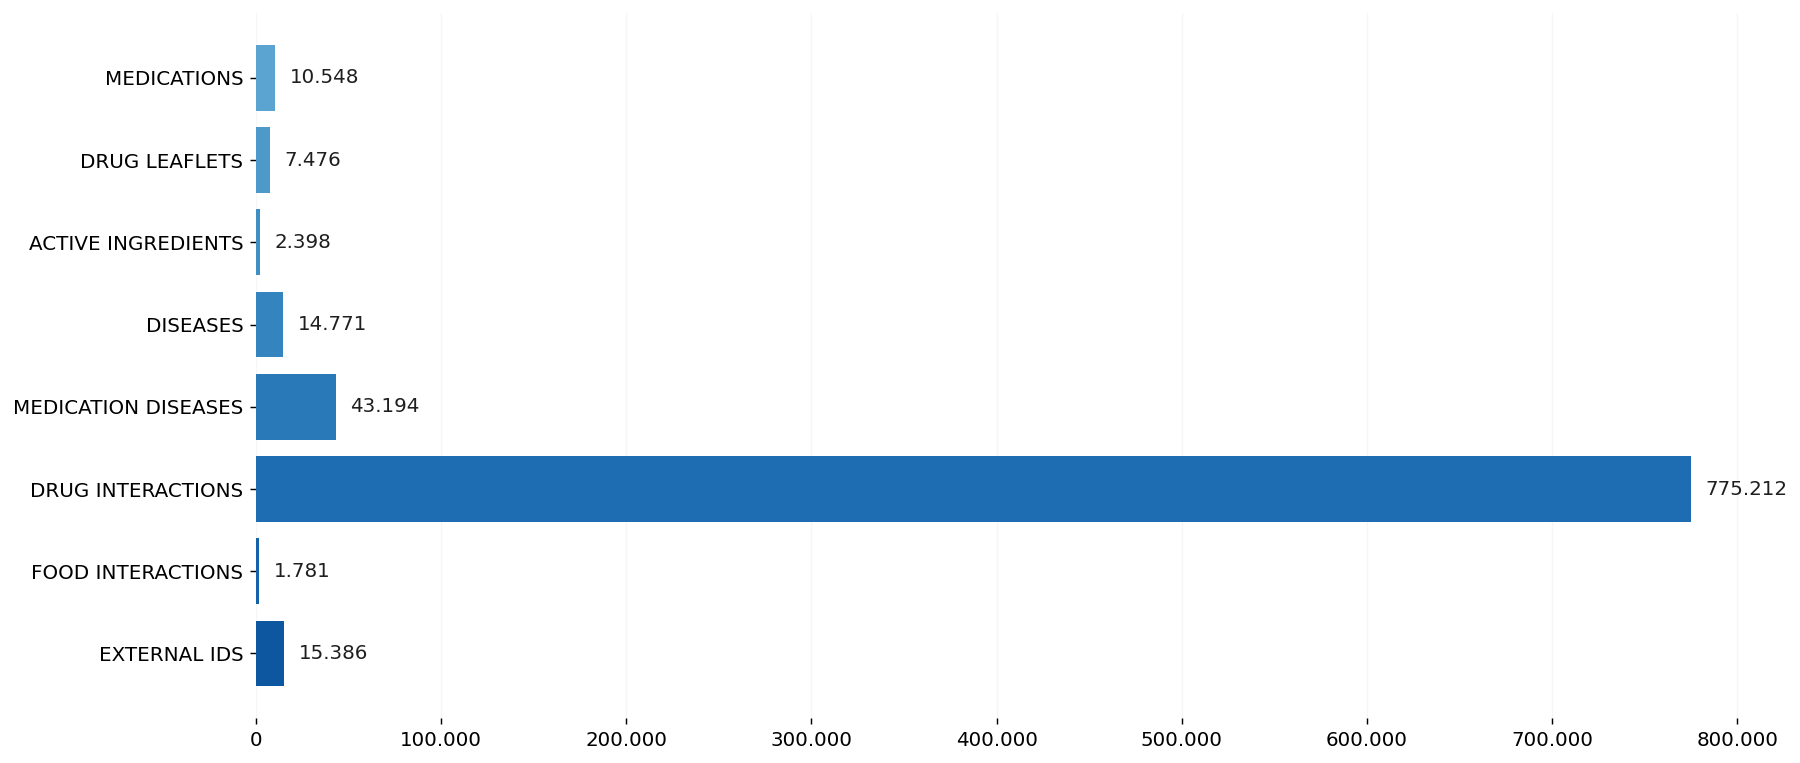

In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# --- Deixe a renderização mais nítida e a fonte consistente ---
mpl.rcParams["figure.dpi"] = 130                 # mais nítido no notebook
mpl.rcParams["font.family"] = "DejaVu Sans"      # fonte única (padrão cross-platform)
mpl.rcParams["font.size"] = 11                   # texto base
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 11

# ----- ORDEM FIXA -----
labels = [
    "MEDICATIONS",
    "DRUG LEAFLETS",
    "ACTIVE INGREDIENTS",
    "DISEASES",
    "MEDICATION DISEASES",
    "DRUG INTERACTIONS",
    "FOOD INTERACTIONS",
    "EXTERNAL IDS",
]

vals_pt = ["10.548", "7.476", "2.398", "14.771", "43.194", "775.212", "1.781", "15.386"]
values = [int(v.replace('.', '')) for v in vals_pt]

# formatador BR: 100000 -> 100.000
fmt_ptbr = lambda x, p=None: f"{int(x):,}".replace(",", ".")
br_fmt = FuncFormatter(fmt_ptbr)

fig, ax = plt.subplots(figsize=(14, 6))

# paleta azul similar
colors = plt.cm.Blues(np.linspace(0.55, 0.85, len(labels)))
bars = ax.barh(labels, values, color=colors, zorder=3)

# primeiro no topo (ordem fixa que você definiu)
ax.invert_yaxis()

# --- só linhas internas, sem contorno externo ---
ax.set_axisbelow(True)
ax.xaxis.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.35, color="#E5E7EB")
ax.yaxis.grid(False)
for side in ["left", "right", "top", "bottom"]:
    ax.spines[side].set_visible(False)

# margem à direita p/ o rótulo não colar
ax.margins(x=0.04)

# rótulos ao fim das barras (fonte igual)
xmax = max(values)
for b, txt in zip(bars, vals_pt):
    w = b.get_width()
    y = b.get_y() + b.get_height()/2
    ax.text(w + xmax*0.01, y, txt, va="center", ha="left", fontsize=11, color="#1F1F1F")

# sem rótulos de eixos/título (como no Excel e no de categorias)
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(br_fmt)

plt.tight_layout()
plt.show()


In [120]:
# Fechar conexão
close_connection_alchemy(engine)